# 04 — Convolutional Neural Networks

Convolution from scratch, visual intuition, and small image classifiers in PyTorch and Keras.

## Learning objectives

You will learn to:

- explain why dense layers ignore useful image structure;
- compute convolution manually;
- understand kernels, channels, feature maps, stride, padding, pooling, and receptive fields;
- visualize how filters respond to patterns;
- construct a small CNN with PyTorch and Keras;
- track tensor shapes through a CNN.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

rng = np.random.default_rng(42)

## 1. Why convolution?

A dense layer treats every input position with a separate parameter. For images this ignores two useful assumptions:

1. **Locality:** nearby pixels form meaningful local patterns.
2. **Translation sharing:** the same feature, such as an edge, can appear anywhere.

A convolutional layer reuses a small kernel across spatial locations. This is called **parameter sharing**.

## 2. Two-dimensional cross-correlation

Deep-learning libraries usually implement cross-correlation while calling it convolution:

$$
Y[i,j]=\sum_{a=0}^{k_h-1}\sum_{b=0}^{k_w-1}X[i+a,j+b]K[a,b].
$$

Classical mathematical convolution flips the kernel; learned CNN kernels make the distinction operationally unimportant because the weights are learned.

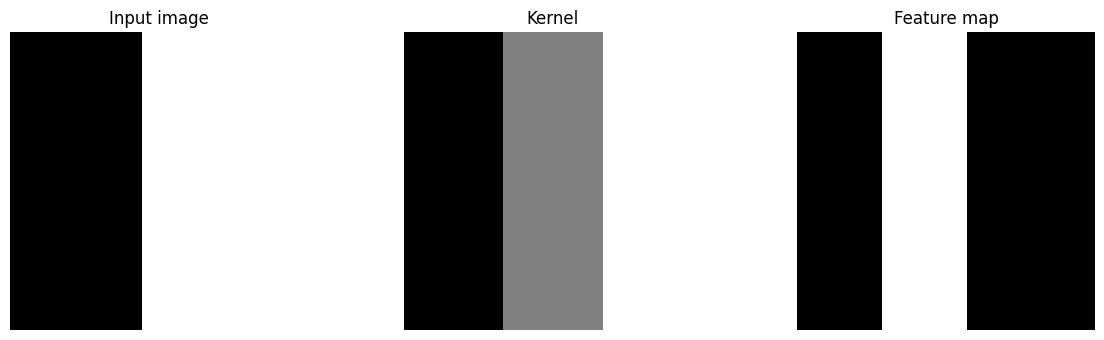

In [2]:
def conv2d_valid(image, kernel):
    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    kh, kw = kernel.shape
    oh = image.shape[0] - kh + 1
    ow = image.shape[1] - kw + 1
    output = np.zeros((oh, ow))

    for i in range(oh):
        for j in range(ow):
            patch = image[i:i+kh, j:j+kw]
            output[i, j] = np.sum(patch * kernel)
    return output

image = np.zeros((9, 9))
image[:, 4:] = 1.0
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])
response = conv2d_valid(image, vertical_edge_kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Input image')
axes[1].imshow(vertical_edge_kernel, cmap='gray')
axes[1].set_title('Kernel')
axes[2].imshow(response, cmap='gray')
axes[2].set_title('Feature map')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

The response has a large magnitude where the local patch changes from dark to light. A trained CNN does not usually receive hand-designed edge kernels; gradient descent learns useful filters from the task loss.

## 3. Stride, padding, and output size

For one spatial dimension, with input size $N$, kernel size $K$, padding $P$, dilation $D$, and stride $S$:

$$
\text{output size}=\left\lfloor\frac{N+2P-D(K-1)-1}{S}+1\right\rfloor.
$$

- **Padding** controls border handling and can preserve size.
- **Stride** controls how far the kernel moves each step.
- **Dilation** spaces kernel elements apart and expands receptive field.

In [3]:
def output_size(n, kernel, stride=1, padding=0, dilation=1):
    return ((n + 2 * padding - dilation * (kernel - 1) - 1) // stride) + 1

examples = [
    (28, 3, 1, 0),
    (28, 3, 1, 1),
    (28, 5, 2, 0),
]
for n, k, s, p in examples:
    print(f'N={n}, K={k}, stride={s}, padding={p} -> output={output_size(n, k, s, p)}')

N=28, K=3, stride=1, padding=0 -> output=26
N=28, K=3, stride=1, padding=1 -> output=28
N=28, K=5, stride=2, padding=0 -> output=12


## 4. Channels and filters

An RGB image has three input channels. A convolutional filter spans all input channels and produces one output feature map. With $C_{in}$ input channels and $C_{out}$ filters, the kernel tensor has shape

$$
(C_{out},C_{in},K_h,K_w)
$$

in PyTorch's convention.

Parameter count:

$$
C_{out}(C_{in}K_hK_w+1)
$$

when each output channel has one bias.

In [4]:
def conv_parameter_count(cin, cout, kh, kw, bias=True):
    return cout * cin * kh * kw + (cout if bias else 0)

print('3 input channels, 32 filters, 3x3 kernels:', conv_parameter_count(3, 32, 3, 3))
print('Equivalent dense mapping from 32x32x3 to 32x32x32 would be enormous by comparison.')

3 input channels, 32 filters, 3x3 kernels: 896
Equivalent dense mapping from 32x32x3 to 32x32x32 would be enormous by comparison.


## 5. Pooling

Pooling reduces spatial resolution. Max pooling keeps the largest activation in each window; average pooling keeps the mean.

Benefits can include:

- lower computation;
- larger effective receptive fields;
- some tolerance to small shifts.

Pooling also discards information. Modern architectures sometimes use strided convolutions or global average pooling instead.

In [5]:
def max_pool2d(image, pool_size=2, stride=2):
    h, w = image.shape
    oh = (h - pool_size) // stride + 1
    ow = (w - pool_size) // stride + 1
    output = np.zeros((oh, ow))
    for i in range(oh):
        for j in range(ow):
            patch = image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            output[i, j] = patch.max()
    return output

sample_matrix = np.arange(1, 17).reshape(4, 4)
print('Input:\n', sample_matrix)
print('2x2 max pooling:\n', max_pool2d(sample_matrix))

Input:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
2x2 max pooling:
 [[ 6.  8.]
 [14. 16.]]


## 6. A real small image dataset

The scikit-learn digits dataset contains $8\times8$ grayscale handwritten digits. It is small enough to train quickly without downloads.

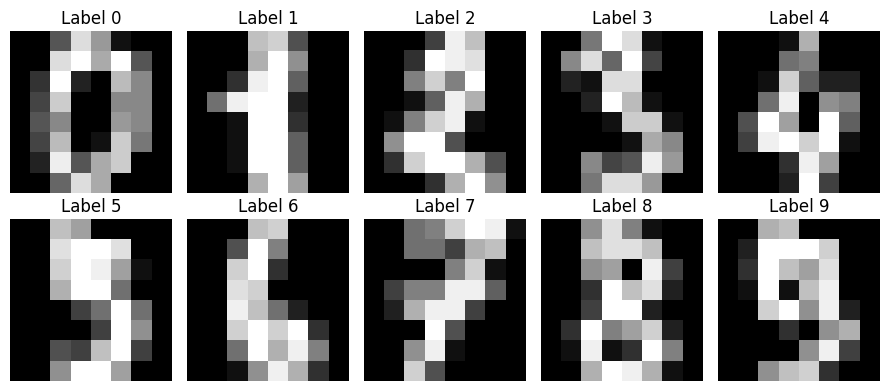

Train shape: (1437, 8, 8) Test shape: (360, 8, 8)


In [6]:
digits = load_digits()
X_images = digits.images.astype(np.float32) / 16.0
y = digits.target

fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for ax, image_i, label_i in zip(axes.ravel(), X_images[:10], y[:10]):
    ax.imshow(image_i, cmap='gray')
    ax.set_title(f'Label {label_i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X_images, y, test_size=0.2, stratify=y, random_state=42
)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

## 7. A CNN in PyTorch

PyTorch images use shape

$$
(\text{batch},\text{channels},\text{height},\text{width}).
$$

Our grayscale images therefore need one channel: `(N, 1, 8, 8)`.

In [7]:
try:
    import torch
    from torch import nn
    from torch.utils.data import TensorDataset, DataLoader

    torch.manual_seed(42)
    Xtr = torch.tensor(X_train[:, None, :, :], dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.long)
    Xte = torch.tensor(X_test[:, None, :, :], dtype=torch.float32)

    train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)

    class SmallCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(1, 8, kernel_size=3, padding=1),  # 8x8 -> 8x8
                nn.ReLU(),
                nn.MaxPool2d(2),                           # 8x8 -> 4x4
                nn.Conv2d(8, 16, kernel_size=3, padding=1),# 4x4 -> 4x4
                nn.ReLU(),
                nn.MaxPool2d(2),                           # 4x4 -> 2x2
            )
            self.classifier = nn.Linear(16 * 2 * 2, 10)

        def forward(self, x):
            x = self.features(x)
            x = torch.flatten(x, start_dim=1)
            return self.classifier(x)

    cnn = SmallCNN()
    optimizer = torch.optim.Adam(cnn.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()
    cnn_losses = []

    for epoch in range(12):
        cnn.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            logits = cnn(xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(xb)
        cnn_losses.append(running_loss / len(train_loader.dataset))

    cnn.eval()
    with torch.no_grad():
        predicted = cnn(Xte).argmax(dim=1).numpy()
    print(cnn)
    print('PyTorch CNN test accuracy:', accuracy_score(y_test, predicted))
except ImportError:
    print('PyTorch is not installed. Install it to run this section.')

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=64, out_features=10, bias=True)
)
PyTorch CNN test accuracy: 0.9666666666666667


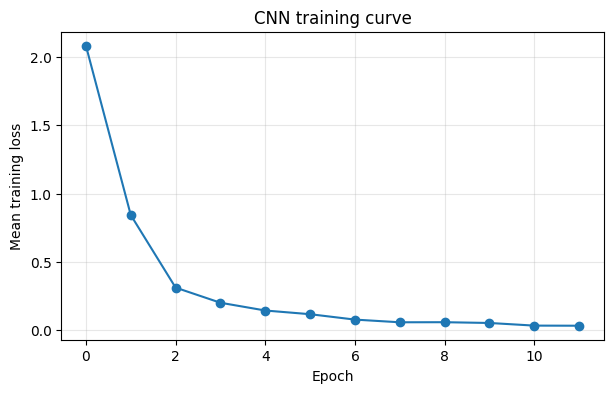

In [8]:
if 'cnn_losses' in globals():
    plt.figure(figsize=(7, 4))
    plt.plot(cnn_losses, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Mean training loss')
    plt.title('CNN training curve')
    plt.grid(alpha=0.3)
    plt.show()

## 8. Inspecting learned feature maps

A feature map shows where one learned filter responds. Early feature maps often behave like edge or texture detectors, though interpretations should be made cautiously.

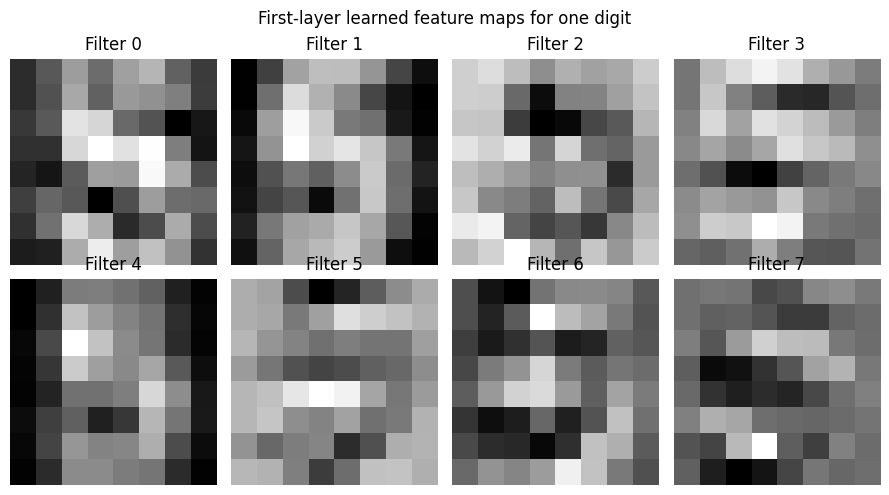

In [9]:
if 'cnn' in globals():
    cnn.eval()
    example = Xte[:1]
    with torch.no_grad():
        first_conv_maps = cnn.features[0](example)[0].numpy()

    fig, axes = plt.subplots(2, 4, figsize=(9, 5))
    for ax, fmap, idx in zip(axes.ravel(), first_conv_maps, range(len(first_conv_maps))):
        ax.imshow(fmap, cmap='gray')
        ax.set_title(f'Filter {idx}')
        ax.axis('off')
    plt.suptitle('First-layer learned feature maps for one digit')
    plt.tight_layout()
    plt.show()

## 9. The equivalent Keras model

TensorFlow/Keras convention is usually `(batch, height, width, channels)`.

In [10]:
try:
    import tensorflow as tf

    tf.random.set_seed(42)
    keras_cnn = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(8, 8, 1)),
        tf.keras.layers.Conv2D(8, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=2),
        tf.keras.layers.Conv2D(16, kernel_size=3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(10, activation='softmax'),
    ])
    keras_cnn.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    history = keras_cnn.fit(
        X_train[..., None], y_train,
        validation_data=(X_test[..., None], y_test),
        epochs=12,
        batch_size=64,
        verbose=0,
    )
    print(keras_cnn.summary())
    print('Keras CNN test metrics:', keras_cnn.evaluate(X_test[..., None], y_test, verbose=0))
except ImportError:
    print('TensorFlow is optional and is not installed in this environment.')
    print('Install it with: pip install tensorflow')

TensorFlow is optional and is not installed in this environment.
Install it with: pip install tensorflow


## 10. Shape tracking checklist

For every CNN layer, write down:

1. batch size;
2. channel count;
3. height and width;
4. kernel size, stride, and padding;
5. resulting parameter count.

Most beginner CNN bugs are shape misunderstandings rather than deep mathematical problems.

## Exercises

1. Implement padded and strided NumPy convolution.
2. Extend the manual convolution to multiple channels and multiple filters.
3. Remove one pooling layer from the PyTorch CNN and fix the classifier input shape.
4. Compare a dense network against the CNN on the digits dataset.
5. Visualize incorrectly classified digits.
6. Add data augmentation using small rotations or shifts and measure the effect.
7. Explain why CNNs can also be applied to one-dimensional text or signal sequences.

## Key takeaways

- CNNs encode locality and parameter sharing.
- A filter produces a feature map by scanning local patches.
- Stride, padding, channels, and pooling determine tensor shapes and receptive fields.
- NumPy makes convolution mechanics visible; frameworks efficiently train many learned filters.
- CNNs remain useful even though transformers dominate many modern vision and NLP systems.